In [1]:
%pip install numpy matplotlib seaborn tensorflow scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.datasets import fashion_mnist

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
list = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

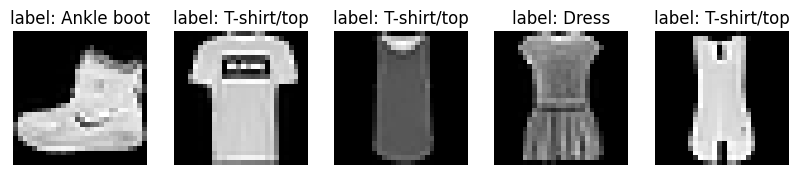

In [14]:
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i], cmap = 'gray')
    plt.title(f"label: {list[y_train[i]]}")
    plt.axis('off')
plt.show()

In [5]:
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

In [6]:
model = Sequential([
    Conv2D(32, activation='relu',kernel_size=(3,3),input_shape = (28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(10, activation='softmax')
])

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [8]:
model.fit(X_train, y_train,epochs=50, batch_size=32, validation_split=0.1)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8524 - loss: 0.4204 - val_accuracy: 0.8870 - val_loss: 0.3216
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8974 - loss: 0.2885 - val_accuracy: 0.8972 - val_loss: 0.2799
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9104 - loss: 0.2448 - val_accuracy: 0.9023 - val_loss: 0.2701
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9214 - loss: 0.2124 - val_accuracy: 0.9105 - val_loss: 0.2486
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9318 - loss: 0.1871 - val_accuracy: 0.9118 - val_loss: 0.2526
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9397 - loss: 0.1637 - val_accuracy: 0.9153 - val_loss: 0.2472
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9465 - loss: 0.1445 - val_accuracy: 0.9100 - val_loss: 0.2743
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9520 - loss: 0.1286 - 

In [9]:
y_pred = np.argmax(model.predict(X_test), axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [10]:
cm = confusion_matrix(y_test, y_pred)

In [11]:
accuracy_score(y_test, y_pred)

0.903

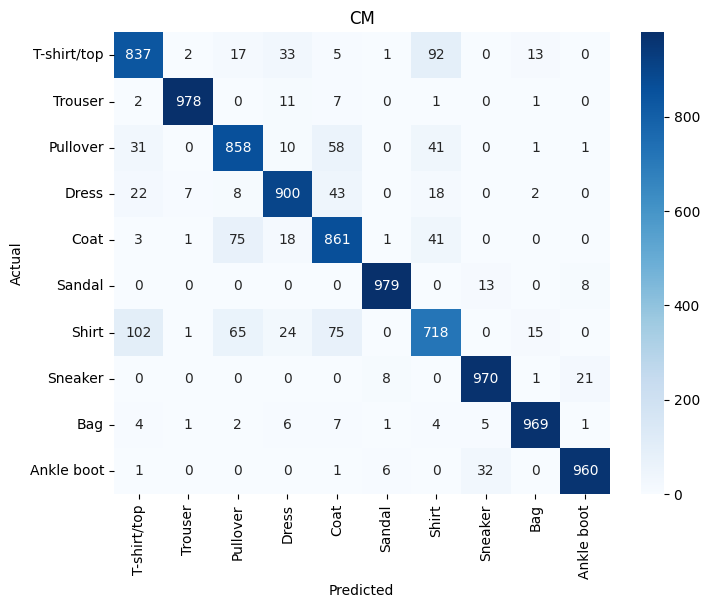

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list, yticklabels=list)
plt.title("CM")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()